---
# INFORMS TutORial text example

Section 4.3 illustrative example: knapsack bandit with a feasibility network relaxation.
---


## Modules and Initial Setup

To set up required packages when using Conda, use:

`conda env create -f environment.yml`


In [2]:
import inspect
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import clear_output, display


def find_project_root(start_path: Path) -> Path:
    """Find the weakly-coupled MDP project root from a notebook directory."""
    for candidate in (start_path, *start_path.parents):
        if (candidate / "wmdp.py").exists() and (candidate / "fnr.py").exists():
            return candidate
    raise RuntimeError("Could not locate the weakly-coupled MDP project root.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from wmdp import *
from fnr import *
from delayedallocation import *
from lagrangian import *
from simulator import Simulator

print("Project root:", PROJECT_ROOT)


Project root: /Users/parshan/Library/CloudStorage/Dropbox/Parshan's Files/Github/INFORMS-Tutorials/weakly-coupled-mdp


## WMDP Example

This notebook implements the illustrative example in Section 4.3 of *Self-Adapting Networks for Weakly Coupled Dynamic Programs*. The instance is the three-product knapsack bandit from Example 3. In each decision period, action `1` means include a product in the assortment and action `0` means leave it out.

The shared knapsack constraints are

$$2a_1 + 10a_2 + 8a_3 \le 14, \qquad 3a_1 + 18a_2 + 15a_3 \le 20.$$

These constraints allow any single product and the pair of products 1 and 3, but exclude products 1 and 2, products 2 and 3, and all three products together. The example is constructed so the FNR policy chooses product 2 in both decision periods and attains value 49, while the Lagrangian greedy policy can be substantially worse.


## Constructing the WMDP

The next cells translate the Section 4.3 knapsack-bandit instance into the tutorial code: three binary component MDPs, two knapsack linking constraints, and a zero-reward terminal period used only so the simulator executes the two decision periods described in the paper.


### Action Set

Each product has the same binary action set. Action `0` means the product is not included in the assortment; action `1` means it is included.


In [3]:
# J is the number of product components.
# T includes periods 0 and 1 from Section 4.3 plus a zero-reward terminal period for simulation.
J = 3
T = 3
FIRST_DECISION_PERIODS = [0, 1]
action_sets = [[0, 1] for _ in range(J)]

print("Action sets:")
action_sets


Action sets:


[[0, 1], [0, 1], [0, 1]]

### Component MDPs

All products start in state `s0`. If product `j` is included in period 0, it may transition to state `s1` in period 1; if it is not included, it remains in `s0`. The transition probabilities and rewards match Section 4.3. Product 2 has the largest immediate reward in `s0`, while product 1 has the largest reward after transitioning to `s1`.


In [4]:
# Rewards for including each product in period 0 state s0.
period0_include_reward = [1.0, 22.0, 0.5]

# Rewards for including each product in period 1 state s1.
period1_high_state_reward = [42.0, 32.0, 11.0]

# Probability of moving from s0 to s1 when the product is included in period 0.
activation_probability = [0.5, 0.5, 1.0]

components = []
for j in range(J):
    state_reward_by_period = [
        [("s0", {0: 0.0, 1: period0_include_reward[j]})],
        [
            ("s0", {0: 0.0, 1: period0_include_reward[j]}),
            ("s1", {0: 0.0, 1: period1_high_state_reward[j]}),
        ],
        [
            ("s0", {0: 0.0, 1: 0.0}),
            ("s1", {0: 0.0, 1: 0.0}),
        ],
    ]

    p = activation_probability[j]
    period0_transition_kernel = {
        ("s0", 0, "s0"): 1.0,
        ("s0", 1, "s0"): 1.0 - p,
        ("s0", 1, "s1"): p,
    }
    period1_terminal_kernel = {
        ("s0", 0, "s0"): 1.0,
        ("s0", 1, "s0"): 1.0,
        ("s1", 0, "s1"): 1.0,
        ("s1", 1, "s1"): 1.0,
    }

    component = build_component(
        component=j,
        actions=action_sets[j],
        state_data_by_period=state_reward_by_period,
        transitions_by_period=[period0_transition_kernel, period1_terminal_kernel],
    )
    components.append(component)

print("Product 2 period-0 state:")
print(components[1].states[0])
print()
print("Product 2 transition kernel from period 0 to period 1:")
print(components[1].P[0])


Product 2 period-0 state:
[(s0,1,{0: 0.0, 1: 22.0})]

Product 2 transition kernel from period 0 to period 1:
{('s0', 0, 's0'): 1.0, ('s0', 1, 's0'): 0.5, ('s0', 1, 's1'): 0.5}


### Linking Constraints

The next cell adds the two knapsack constraints from Example 3 and Section 4.3. Only action `1` consumes capacity; action `0` has coefficient zero.


In [5]:
# Coefficients in the two knapsack constraints:
#   2a1 + 10a2 + 8a3 <= 14
#   3a1 + 18a2 + 15a3 <= 20
# Component indices are zero based, so product 1 is component 0.
size_capacity = {
    (0, 1): 2.0,
    (1, 1): 10.0,
    (2, 1): 8.0,
}
weight_capacity = {
    (0, 1): 3.0,
    (1, 1): 18.0,
    (2, 1): 15.0,
}

linking_constraints = build_linking_constraints(
    action_sets=action_sets,
    constraint_coefficients=[size_capacity, weight_capacity],
    rhs_values=[14.0, 20.0],
)

print("Linking constraints:")
print(linking_constraints)


Linking constraints:
+ 2.0 * y_{0,0,1} + 10.0 * y_{0,1,1} + 8.0 * y_{0,2,1} <= 14.0
+ 3.0 * y_{1,0,1} + 18.0 * y_{1,1,1} + 15.0 * y_{1,2,1} <= 20.0


### Assembling the WMDP

The next cell combines the three component MDPs with the shared knapsack constraints. This is the Section 4.3 WMDP instance used by the Lagrangian relaxation and the feasibility network relaxation below.


In [6]:
# Combine the patient component MDPs and the shared resource constraints into one WMDP.
wmdp = build_wmdp(
    components=components,
    linking_constraints=linking_constraints,
)

print(wmdp)


WMDP(J=3, T=3, num_constraints=2)


### The WMDP size

The feasible joint actions are exactly the action vectors permitted by the two knapsack constraints. In this instance they are `(0,0,0)`, each singleton product, and the pair `(1,0,1)`.


In [7]:
# Count the joint states and joint actions that an exact dynamic program or exact LP would enumerate.
state_counts_by_period = {
    t: len(wmdp.generate_states(t))
    for t in range(wmdp.T)
}

# The feasible joint action space keeps only outreach plans satisfying the two resource budgets.
feasible_actions = [
    tuple(action)
    for action, _ in wmdp.generate_feasible_actions()
]
feasible_action_count = len(feasible_actions)

# An exact recursion or exact LP would consider every feasible action in every joint state.
state_action_counts_by_period = {
    t: state_counts_by_period[t] * feasible_action_count
    for t in range(0, wmdp.T)
}

total_joint_states = sum(state_counts_by_period.values())
total_state_action_pairs = sum(state_action_counts_by_period.values())

print("Exact state-action enumeration using feasible actions:")
for t, count in state_action_counts_by_period.items():
    print(f"  period {t}: {state_counts_by_period[t]} states x {feasible_action_count} actions = {count}")
print(f"Total state-action pairs across {wmdp.T} periods: {total_state_action_pairs}")
print()

Exact state-action enumeration using feasible actions:
  period 0: 1 states x 5 actions = 5
  period 1: 8 states x 5 actions = 40
  period 2: 8 states x 5 actions = 40
Total state-action pairs across 3 periods: 85



## The baseline: Lagrangian relaxation

As a baseline, we solve the expectation-relaxed Lagrangian model. This model enforces the two knapsack constraints in expectation over marginal component flows, so its optimistic bound can be loose for the Section 4.3 instance.


### <b>Construct</b>: Building the Lagrangian Relaxation

The next cell constructs the expectation-relaxed model for the knapsack bandit. It keeps product-level marginal flows and replaces pathwise knapsack feasibility with expected capacity constraints in each period.


In [8]:
# Construct the expectation-relaxed Lagrangian model.
# The model keeps component-level marginal flows and enforces resources only in expectation.
lagrangian_model = Lagrangian(wmdp)


Set parameter Username
Set parameter LicenseID to value 2809918
Academic license - for non-commercial use only - expires 2027-04-17


### <b>Optimize</b>: Solving the Lagrangian Relaxation

The next cell solves the relaxed LP and reports expected capacity use. Section 4.3 reports a Lagrangian bound of about 69.667 for the two decision periods; the zero-reward terminal period does not affect that value.


In [9]:
# Solve the Lagrangian relaxation and inspect expected resource use by period and constraint.
lagrangian_result = lagrangian_model.optimize()

print("Objective value: ", lagrangian_result.objective_value)

print("\nExpected resource use:")
for (period, constraint), value in lagrangian_result.expected_resource_use.items():
    budget = wmdp.linking_constraints.b[constraint]
    print(f"  period {period}, constraint {constraint}: {value:.3f} / {budget:.3f}")


Optimizing...
	done.
Lagrangian model size: vars=30 constrs=21 nonzeros=80 time=0.0037240982055664062s
Objective value:  69.66666666666667

Expected resource use:
  period 0, constraint 0: 11.444 / 14.000
  period 0, constraint 1: 20.000 / 20.000
  period 1, constraint 0: 11.333 / 14.000
  period 1, constraint 1: 20.000 / 20.000
  period 2, constraint 0: 0.000 / 14.000
  period 2, constraint 1: 0.000 / 20.000


### Simulating the Lagrangian Policy

The tutorial policy samples from the Lagrangian marginals and repairs infeasible sampled actions online. This is a feasible executable policy derived from the relaxation, not the exact greedy policy calculation reported in the paper.


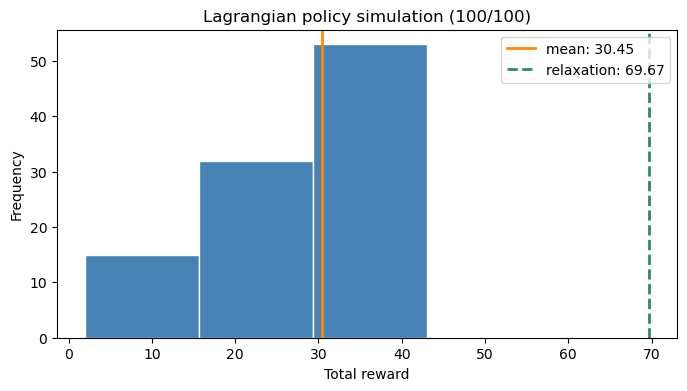

Mean total reward over 100 simulations: 30.450
Most common action paths:
  ((1, 0, 0), (1, 0, 0)): 68
  ((1, 0, 0), (0, 1, 0)): 32


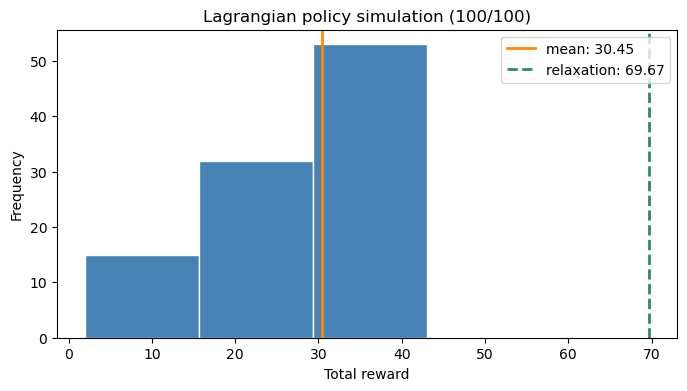

In [10]:
# Simulate the repaired Lagrangian policy and plot total realized rewards over the two decision periods.
num_simulations = 100
lagrangian_simulator = Simulator(wmdp, lagrangian_result.policy)
lagrangian_total_rewards = []
lagrangian_action_paths = []

fig, ax = plt.subplots(figsize=(8, 4))

for simulation_index in range(num_simulations):
    simulation_result = lagrangian_simulator.simulate()
    lagrangian_total_rewards.append(simulation_result["total_reward"])
    lagrangian_action_paths.append(tuple(tuple(action) for action in simulation_result["actions"]))

    ax.clear()
    ax.hist(
        lagrangian_total_rewards,
        bins=min(30, max(1, len(set(lagrangian_total_rewards)))),
        color="steelblue",
        edgecolor="white",
    )
    sample_mean = sum(lagrangian_total_rewards) / len(lagrangian_total_rewards)
    ax.axvline(
        sample_mean,
        color="darkorange",
        linewidth=2,
        label=f"mean: {sample_mean:.2f}",
    )
    ax.axvline(
        lagrangian_result.objective_value,
        color="seagreen",
        linewidth=2,
        linestyle="--",
        label=f"relaxation: {lagrangian_result.objective_value:.2f}",
    )
    ax.set_title(f"Lagrangian policy simulation ({simulation_index + 1}/{num_simulations})")
    ax.set_xlabel("Total reward")
    ax.set_ylabel("Frequency")
    ax.legend(loc="upper right")

    clear_output(wait=True)
    display(fig)
    time.sleep(0.05)

print(f"Mean total reward over {num_simulations} simulations: {sum(lagrangian_total_rewards) / len(lagrangian_total_rewards):.3f}")
print("Most common action paths:")
for path, count in sorted(
    {path: lagrangian_action_paths.count(path) for path in set(lagrangian_action_paths)}.items(),
    key=lambda item: item[1],
    reverse=True,
)[:5]:
    print(f"  {path}: {count}")


## Self-Adapting Network Relaxations

We now build and solve the feasible network relaxation (FNR) for the same knapsack bandit. The network represents exactly the feasible product-assortment choices under the two knapsack constraints.


### <b>Construct</b>: Building the Feasibility Network Relaxation

The next cell constructs the reduced layered network from the two knapsack constraints. Each root-to-terminal path corresponds to one feasible action vector.


In [11]:
# Build the FNR network from the two knapsack constraints.
# Network paths encode feasible product-assortment decisions.
network = construct_fnr_network(wmdp.linking_constraints)
print("Network size:")
print(network.get_size())


Network size:
{'nodes': 6, 'arcs': 8, 'max_width': 2}


### Visualizing the Network

The next cell draws the feasibility network. Layers correspond to products, and arcs correspond to excluding or including a product while tracking remaining knapsack capacity.


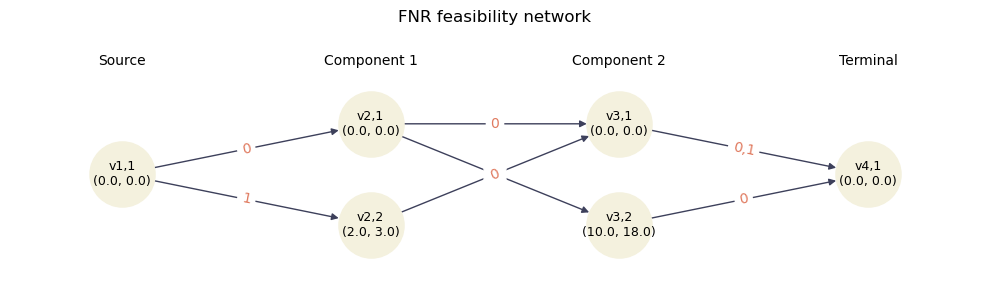

In [12]:
# Draw the layered feasibility network for the Section 4.3 knapsack instance.
draw_fnr_network(network, figsize=(10, 3))


<b>How many actions does this represent?</b>

The next code enumerates all feasible actions, each represented as a path of the network.

In [13]:
feasible_actions = [
    tuple(action)
    for action, _ in wmdp.generate_feasible_actions()
]

print(f"Feasible actions (total: {len(feasible_actions)}):")
for action in feasible_actions:
    print("\tAction " + str(action))

Feasible actions (total: 5):
	Action (0, 0, 0)
	Action (0, 0, 1)
	Action (0, 1, 0)
	Action (1, 0, 0)
	Action (1, 0, 1)


<b>Linear programming construction</b>

The next cell constructs the FNR LP over the same component flows, linked to network-arc flows that encode feasible action vectors.


In [14]:
# Construct the FNR linear-programming model for the Section 4.3 knapsack bandit.
FNR_model = FNR(wmdp, network)


## <b>Optimize</b>: Solving the FNR Model

The next cell solves the FNR linear program. Section 4.3 reports an FNR bound of 49, obtained by choosing product 2 in both periods and accounting for its period-1 transition.


In [15]:
# Solve the FNR model and report the expected total reward and positive marginal action flows.
fnr_result = FNR_model.optimize()

print("Objective value: ", fnr_result.objective_value)
print("Positive marginals:")
for key, value in sorted(fnr_result.marginal_flows.items()):
    if value > 1e-8:
        print(f"  {key}: {value:.3f}")


Optimizing...
	done.
FNR model size: vars=70 constrs=57 nonzeros=175 time=0.00021505355834960938s
Objective value:  49.0
Positive marginals:
  (0, 0, 's0', 0): 1.000
  (0, 1, 's0', 1): 1.000
  (0, 2, 's0', 0): 1.000
  (1, 0, 's0', 0): 1.000
  (1, 1, 's0', 1): 0.500
  (1, 1, 's1', 1): 0.500
  (1, 2, 's0', 0): 1.000
  (2, 0, 's0', 0): 1.000
  (2, 1, 's0', 0): 0.500
  (2, 1, 's1', 0): 0.500
  (2, 2, 's0', 0): 1.000


### Simulating the FNR Policy

The FNR policy follows positive network flow when available. For this instance, Section 4.3 predicts action `(0,1,0)` in both decision periods for every state reachable from the initial state.


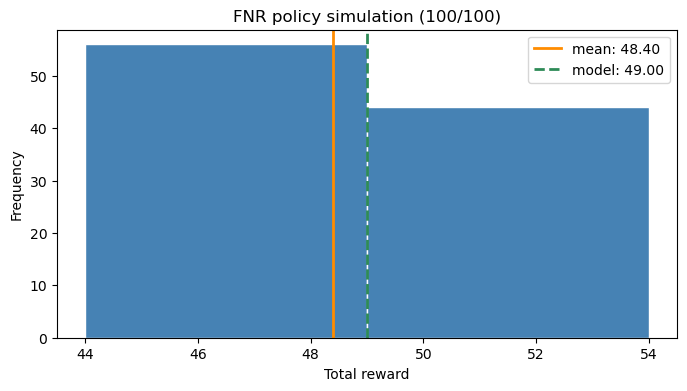

Mean total reward over 100 simulations: 48.400
Action paths observed:
  ((0, 1, 0), (0, 1, 0)): 100


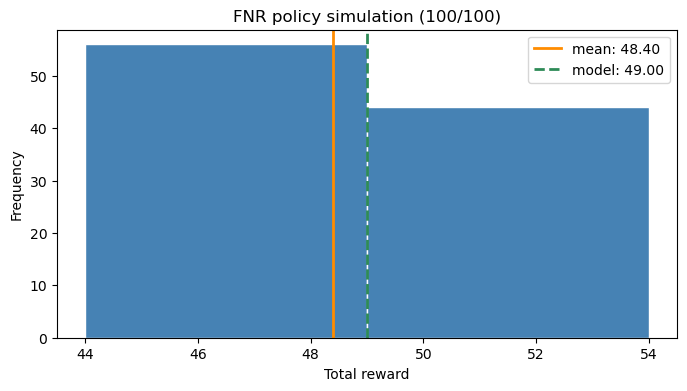

In [16]:
# Simulate the FNR policy and plot total realized rewards over the two decision periods.
num_simulations = 100
fnr_simulator = Simulator(wmdp, fnr_result.policy)
fnr_total_rewards = []
fnr_action_paths = []

fig, ax = plt.subplots(figsize=(8, 4))

for simulation_index in range(num_simulations):
    simulation_result = fnr_simulator.simulate()
    fnr_total_rewards.append(simulation_result["total_reward"])
    fnr_action_paths.append(tuple(tuple(action) for action in simulation_result["actions"]))

    ax.clear()
    ax.hist(
        fnr_total_rewards,
        bins=min(30, max(1, len(set(fnr_total_rewards)))),
        color="steelblue",
        edgecolor="white",
    )
    sample_mean = sum(fnr_total_rewards) / len(fnr_total_rewards)
    ax.axvline(
        sample_mean,
        color="darkorange",
        linewidth=2,
        label=f"mean: {sample_mean:.2f}",
    )
    ax.axvline(
        fnr_result.objective_value,
        color="seagreen",
        linewidth=2,
        linestyle="--",
        label=f"model: {fnr_result.objective_value:.2f}",
    )
    ax.set_title(f"FNR policy simulation ({simulation_index + 1}/{num_simulations})")
    ax.set_xlabel("Total reward")
    ax.set_ylabel("Frequency")
    ax.legend(loc="upper right")

    clear_output(wait=True)
    display(fig)
    time.sleep(0.05)

clear_output(wait=True)
display(fig)
print(f"Mean total reward over {num_simulations} simulations: {sum(fnr_total_rewards) / len(fnr_total_rewards):.3f}")
print("Action paths observed:")
for path, count in sorted(
    {path: fnr_action_paths.count(path) for path in set(fnr_action_paths)}.items(),
    key=lambda item: item[1],
    reverse=True,
):
    print(f"  {path}: {count}")


## Delayed Allocation

We now solve the delayed-allocation model for the same Section 4.3 knapsack bandit. The model starts with a deliberately small action set containing only the all-zero action `(0, 0, 0)` in every period, then performs exactly three refinement iterations using the exact linking-IP separation oracle.


### <b>Construct</b>: Initial Restricted Action Set

The next cell initializes delayed allocation with one feasible joint action in each period: exclude every product. Refinement can then add feasible actions with positive reduced cost.


In [17]:
# Start delayed allocation with one available joint action in each period: exclude every product.
initial_actions = {
    period: [tuple(0 for _ in range(J))]
    for period in range(wmdp.T)
}

print("Initial delayed-allocation actions:")
for period, actions in initial_actions.items():
    print(f"  period {period}: {actions}")


Initial delayed-allocation actions:
  period 0: [(0, 0, 0)]
  period 1: [(0, 0, 0)]
  period 2: [(0, 0, 0)]


In [18]:
# Build and solve the restricted delayed-allocation model.
DA_model = DelayedAllocationModel(wmdp, initial_actions=initial_actions)
delayed_allocation_result = DA_model.optimize()

print("Initial restricted objective value:", delayed_allocation_result.objective_value)
print("Positive pi actions:")
for period, actions in delayed_allocation_result.positive_pi_actions.items():
    print(f"  period {period}: {actions}")


Initial restricted objective value: -0.0
Positive pi actions:
  period 0: [((0, 0, 0), 1.0)]
  period 1: [((0, 0, 0), 1.0)]
  period 2: [((0, 0, 0), 1.0)]


### <b>Refine</b>: Three Delayed-Allocation Iterations

Each refinement solves a pricing problem for each period and adds at most one improving feasible joint action per period. The loop below intentionally stops after three iterations, even if more refinement were possible.


In [19]:
# Run exactly three delayed-allocation refinement iterations.
exact_separation = LinkingIPSeparation()

def snapshot_delayed_allocation(iteration, result):
    action_sets = {
        period: list(actions)
        for period, actions in DA_model.action_set.items()
    }
    positive_actions = {
        period: [action for action, value in actions if value > DA_model.tolerance]
        for period, actions in result.positive_pi_actions.items()
    }
    return {
        "iteration": iteration,
        "objective": result.objective_value,
        "num_new_actions": result.num_new_actions,
        "added_actions": result.added_actions,
        "action_sets": action_sets,
        "positive_actions": positive_actions,
        "policy": result.policy,
        "action_set_size": {period: len(actions) for period, actions in action_sets.items()},
    }

delayed_allocation_history = [snapshot_delayed_allocation(0, delayed_allocation_result)]

for iteration in range(1, 4):
    delayed_allocation_result = DA_model.refine(
        duals=delayed_allocation_result.duals,
        separation_method=exact_separation,
        verbose=True,
    )
    delayed_allocation_history.append(snapshot_delayed_allocation(iteration, delayed_allocation_result))

print("Delayed-allocation refinement history:")
for row in delayed_allocation_history:
    print(
        f"  iteration {row['iteration']}: "
        f"objective={row['objective']:.3f}, "
        f"new_actions={row['num_new_actions']}, "
        f"action_set_size={row['action_set_size']}"
    )



	Refining DA model...
		Period 0: added actions
			(0, 1, 0) (reduced cost = 22)
		Period 1: added actions
			(1, 0, 1) (reduced cost = 53)

	Refining DA model...
		Period 0: added actions
			(1, 0, 1) (reduced cost = 10.5)
		Period 1: added actions
			(0, 1, 0) (reduced cost = 30.5)

	Refining DA model...
Delayed-allocation refinement history:
  iteration 0: objective=-0.000, new_actions=0, action_set_size={0: 1, 1: 1, 2: 1}
  iteration 1: objective=23.500, new_actions=2, action_set_size={0: 2, 1: 2, 2: 1}
  iteration 2: objective=49.000, new_actions=2, action_set_size={0: 3, 1: 3, 2: 1}
  iteration 3: objective=49.000, new_actions=0, action_set_size={0: 3, 1: 3, 2: 1}


In [20]:
# Inspect the actions available after three refinement iterations.
print("Delayed-allocation action sets after three iterations:")
for period, actions in DA_model.action_set.items():
    print(f"  period {period}:")
    for action in actions:
        marker = "*" if any(
            positive_action == action
            for positive_action, _ in delayed_allocation_result.positive_pi_actions[period]
        ) else " "
        print(f"    {marker} {action}")

print("\nPositive pi actions in the final restricted solution:")
for period, actions in delayed_allocation_result.positive_pi_actions.items():
    print(f"  period {period}: {actions}")


Delayed-allocation action sets after three iterations:
  period 0:
      (0, 0, 0)
    * (0, 1, 0)
      (1, 0, 1)
  period 1:
      (0, 0, 0)
      (1, 0, 1)
    * (0, 1, 0)
  period 2:
    * (0, 0, 0)

Positive pi actions in the final restricted solution:
  period 0: [((0, 1, 0), 1.0)]
  period 1: [((0, 1, 0), 1.0)]
  period 2: [((0, 0, 0), 1.0)]


### Simulating the Delayed-Allocation Policy

The policy induced by the delayed-allocation solution samples from the positive restricted action vertices in each period and state. After three refinement iterations, compare its realized value with the Lagrangian and FNR policies.


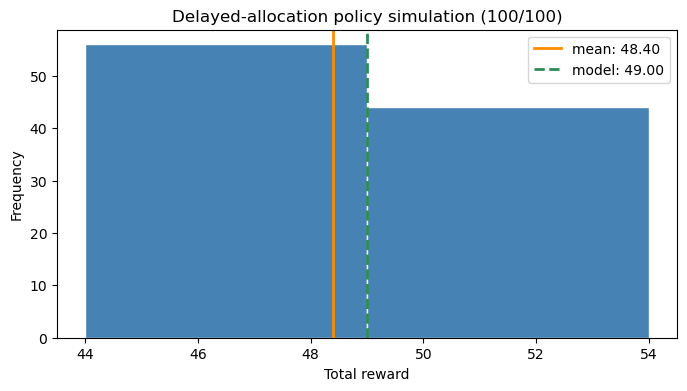

Mean total reward over 100 simulations: 48.400
Action paths observed:
  ((0, 1, 0), (0, 1, 0)): 100


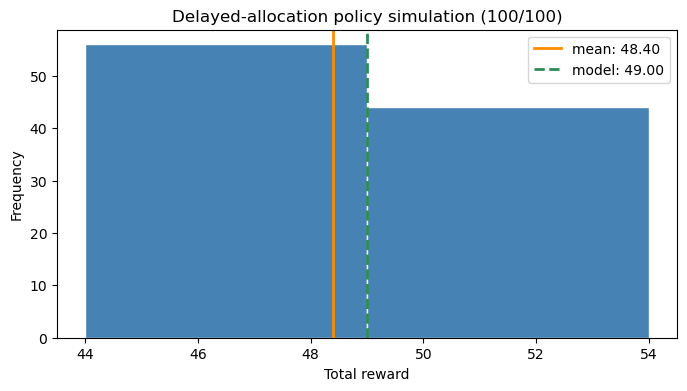

In [21]:
# Simulate the delayed-allocation policy after three refinement iterations.
num_simulations = 100
delayed_allocation_simulator = Simulator(wmdp, delayed_allocation_result.policy)
delayed_allocation_total_rewards = []
delayed_allocation_action_paths = []

fig, ax = plt.subplots(figsize=(8, 4))

for simulation_index in range(num_simulations):
    simulation_result = delayed_allocation_simulator.simulate()
    delayed_allocation_total_rewards.append(simulation_result["total_reward"])
    delayed_allocation_action_paths.append(tuple(tuple(action) for action in simulation_result["actions"]))

    ax.clear()
    ax.hist(
        delayed_allocation_total_rewards,
        bins=min(30, max(1, len(set(delayed_allocation_total_rewards)))),
        color="steelblue",
        edgecolor="white",
    )
    sample_mean = sum(delayed_allocation_total_rewards) / len(delayed_allocation_total_rewards)
    ax.axvline(
        sample_mean,
        color="darkorange",
        linewidth=2,
        label=f"mean: {sample_mean:.2f}",
    )
    ax.axvline(
        delayed_allocation_result.objective_value,
        color="seagreen",
        linewidth=2,
        linestyle="--",
        label=f"model: {delayed_allocation_result.objective_value:.2f}",
    )
    ax.set_title(f"Delayed-allocation policy simulation ({simulation_index + 1}/{num_simulations})")
    ax.set_xlabel("Total reward")
    ax.set_ylabel("Frequency")
    ax.legend(loc="upper right")

    clear_output(wait=True)
    display(fig)
    time.sleep(0.05)

clear_output(wait=True)
display(fig)
print(f"Mean total reward over {num_simulations} simulations: {sum(delayed_allocation_total_rewards) / len(delayed_allocation_total_rewards):.3f}")
print("Action paths observed:")
for path, count in sorted(
    {path: delayed_allocation_action_paths.count(path) for path in set(delayed_allocation_action_paths)}.items(),
    key=lambda item: item[1],
    reverse=True,
):
    print(f"  {path}: {count}")


## Value of Self-Adaptation Relative to the Baseline

The Section 4.3 FNR bound and policy value are 49. The Lagrangian relaxation has a looser optimistic bound, while feasible policies derived from Lagrangian repair and delayed allocation must be evaluated separately. The comparison below reports model objectives and simulated feasible policy means from this notebook.


In [22]:
lagrangian_mean = sum(lagrangian_total_rewards) / len(lagrangian_total_rewards)
fnr_mean = sum(fnr_total_rewards) / len(fnr_total_rewards)
delayed_allocation_mean = sum(delayed_allocation_total_rewards) / len(delayed_allocation_total_rewards)

print("Reference values from Section 4.3:")
print("  FNR bound and policy value: 49.000")
print("  Lagrangian bound:           69.667")
print("  Lagrangian greedy policy:   39.000")
print()
print("Model objective values in this notebook:")
print(f"  Lagrangian relaxation: {lagrangian_result.objective_value:.3f}")
print(f"  FNR model:             {fnr_result.objective_value:.3f}")
print(f"  Delayed allocation:    {delayed_allocation_result.objective_value:.3f}")
print()
print("Simulated feasible policy values:")
print(f"  Repaired Lagrangian policy mean: {lagrangian_mean:.3f}")
print(f"  FNR policy mean:                 {fnr_mean:.3f}")
print(f"  Delayed-allocation policy mean:  {delayed_allocation_mean:.3f}")
print(f"  DA improvement over Lagrangian:  {delayed_allocation_mean - lagrangian_mean:.3f}")
print(f"  DA gap versus FNR:               {fnr_mean - delayed_allocation_mean:.3f}")


Reference values from Section 4.3:
  FNR bound and policy value: 49.000
  Lagrangian bound:           69.667
  Lagrangian greedy policy:   39.000

Model objective values in this notebook:
  Lagrangian relaxation: 69.667
  FNR model:             49.000
  Delayed allocation:    49.000

Simulated feasible policy values:
  Repaired Lagrangian policy mean: 30.450
  FNR policy mean:                 48.400
  Delayed-allocation policy mean:  48.400
  DA improvement over Lagrangian:  17.950
  DA gap versus FNR:               0.000


## Delayed-Allocation Progression Plots

The final plots summarize how delayed allocation improves as actions are generated. The first plot tracks the delayed-allocation model objective by refinement iteration, with the Lagrangian and FNR objectives as reference lines. The second plot evaluates the executable delayed-allocation policy at each iteration and compares it with the repaired Lagrangian policy and the FNR policy.


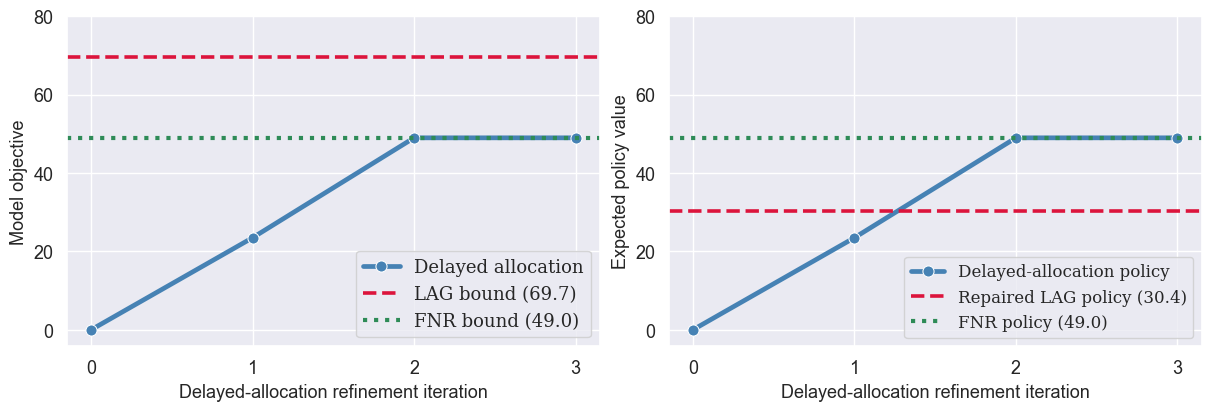

Delayed-allocation progression values:
  iteration 0: model_bound=-0.000, policy_value=0.000
  iteration 1: model_bound=23.500, policy_value=23.500
  iteration 2: model_bound=49.000, policy_value=49.000
  iteration 3: model_bound=49.000, policy_value=49.000


In [23]:
# Plot delayed-allocation bound and policy-value progression.
from collections import defaultdict

try:
    import seaborn as sns
except ModuleNotFoundError:
    sns = None
    print("seaborn is not installed; using a matplotlib fallback for these line plots.")


def evaluate_policy_exactly(wmdp, policy):
    """Compute the exact expected total reward of a deterministic policy."""
    state_distribution = {tuple(wmdp.generate_states(0)[0]): 1.0}
    expected_reward = 0.0

    for period in range(wmdp.T - 1):
        next_distribution = defaultdict(float)
        for state_tuple, state_probability in state_distribution.items():
            state = list(state_tuple)
            action = tuple(policy.get_action(period=period, state=state))
            expected_reward += state_probability * sum(
                component_state.reward[action[component]]
                for component, component_state in enumerate(state)
            )

            component_next_options = []
            for component, component_state in enumerate(state):
                component_model = wmdp.state_space.S[component]
                transition_kernel = component_model.P[period]
                options = []
                for next_state in component_model.states[period + 1]:
                    probability = transition_kernel.get(
                        (component_state.label, action[component], next_state.label),
                        0.0,
                    )
                    if probability > 0.0:
                        options.append((next_state, probability))
                component_next_options.append(options)

            next_states = [([], 1.0)]
            for options in component_next_options:
                expanded = []
                for prefix, prefix_probability in next_states:
                    for next_state, transition_probability in options:
                        expanded.append(
                            (prefix + [next_state], prefix_probability * transition_probability)
                        )
                next_states = expanded

            for next_state, transition_probability in next_states:
                next_distribution[tuple(next_state)] += state_probability * transition_probability

        state_distribution = dict(next_distribution)

    return expected_reward


progression_rows = []
for row in delayed_allocation_history:
    progression_rows.append(
        {
            "iteration": row["iteration"],
            "model_bound": row["objective"],
            "policy_value": evaluate_policy_exactly(wmdp, row["policy"]),
        }
    )

iterations = [row["iteration"] for row in progression_rows]
da_bounds = [row["model_bound"] for row in progression_rows]
da_policy_values = [row["policy_value"] for row in progression_rows]
method_colors = {
    "Delayed allocation": "steelblue",
    "LAG": "crimson",
    "FNR": "seagreen",
}
fnr_policy_value = evaluate_policy_exactly(wmdp, fnr_result.policy)

shared_y_values = (
    da_bounds
    + da_policy_values
    + [
        lagrangian_result.objective_value,
        fnr_result.objective_value,
        lagrangian_mean,
        fnr_policy_value,
    ]
)
y_min = min(shared_y_values)
y_max = max(shared_y_values)
y_padding = max(1.0, 0.06 * (y_max - y_min))
shared_ylim = (y_min - y_padding, y_max + y_padding)

if sns is not None:
    # sns.set_theme(style="whitegrid")
    sns.set_theme(style="darkgrid")
else:
    plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

plt.rcParams.update(
    {
        "font.family": "serif",
        "mathtext.fontset": "cm",
        "axes.unicode_minus": False,
    }
)

if sns is not None:
    sns.lineplot(
        x=iterations,
        y=da_bounds,
        marker="o",
        markersize=8,
        linewidth=3.4,
        color=method_colors["Delayed allocation"],
        ax=axes[0],
        label="Delayed allocation",
    )
else:
    axes[0].plot(
        iterations,
        da_bounds,
        marker="o",
        markersize=8,
        linewidth=3.4,
        color=method_colors["Delayed allocation"],
        label="Delayed allocation",
    )
axes[0].axhline(
    lagrangian_result.objective_value,
    color=method_colors["LAG"],
    linestyle="--",
    linewidth=2.6,
    label=f"LAG bound ({lagrangian_result.objective_value:.1f})",
)
axes[0].axhline(
    fnr_result.objective_value,
    color=method_colors["FNR"],
    linestyle=":",
    linewidth=3.0,
    label=f"FNR bound ({fnr_result.objective_value:.1f})",
)
# axes[0].set_title("Bound progression")
axes[0].set_xlabel("Delayed-allocation refinement iteration",fontsize=13)
axes[0].set_ylabel("Model objective",fontsize=13)
axes[0].set_xticks(iterations)
axes[0].set_xticklabels(iterations,fontsize=13)
axes[0].set_ylim(shared_ylim)
axes[0].set_yticks([0,20,40,60,80])
axes[0].set_yticklabels([0,20,40,60,80],fontsize=13)
axes[0].legend(loc="lower right",fontsize=13)

if sns is not None:
    sns.lineplot(
        x=iterations,
        y=da_policy_values,
        marker="o",
        markersize=8,
        linewidth=3.4,
        color=method_colors["Delayed allocation"],
        ax=axes[1],
        label="Delayed-allocation policy",
    )
else:
    axes[1].plot(
        iterations,
        da_policy_values,
        marker="o",
        markersize=8,
        linewidth=3.4,
        color=method_colors["Delayed allocation"],
        label="Delayed-allocation policy",
    )
axes[1].axhline(
    lagrangian_mean,
    color=method_colors["LAG"],
    linestyle="--",
    linewidth=2.6,
    label=f"Repaired LAG policy ({lagrangian_mean:.1f})",
)
axes[1].axhline(
    fnr_policy_value,
    color=method_colors["FNR"],
    linestyle=":",
    linewidth=3.0,
    label=f"FNR policy ({fnr_policy_value:.1f})",
)
# axes[1].set_title("Policy lower-bound progression")
axes[1].set_xlabel("Delayed-allocation refinement iteration",fontsize=13)
axes[1].set_ylabel("Expected policy value",fontsize=13)
axes[1].set_xticks(iterations)
axes[1].set_xticklabels(iterations,fontsize=13)
axes[1].set_ylim(shared_ylim)
axes[1].set_yticks([0,20,40,60,80])
axes[1].set_yticklabels([0,20,40,60,80],fontsize=13)
axes[1].legend(loc="lower right",fontsize=12)

plt.show()

progression_pdf_path = Path("delayed_allocation_progression.pdf")
fig.savefig(progression_pdf_path, format="pdf", bbox_inches="tight")
# print(f"Saved progression plots to {progression_pdf_path.resolve()}")

print("Delayed-allocation progression values:")
for row in progression_rows:
    print(
        f"  iteration {row['iteration']}: "
        f"model_bound={row['model_bound']:.3f}, "
        f"policy_value={row['policy_value']:.3f}"
    )


## Final Model Sizes

The next cell compares the final optimization-model sizes for the Lagrangian relaxation, the FNR model, and the converged delayed-allocation model. The reported size is the number of variables plus the number of constraints in the underlying Gurobi model.


In [24]:
def current_model_size(model_owner):
    """Return variable, constraint, and total size for a Gurobi-backed model."""
    model = getattr(model_owner, "model", model_owner)
    model.update()
    variables = model.NumVars
    constraints = model.NumConstrs
    return {
        "variables": variables,
        "constraints": constraints,
        "variables_plus_constraints": variables + constraints,
        "nonzeros": model.NumNZs,
    }


model_size_summary = {
    "LAG": current_model_size(lagrangian_model),
    "FNR": current_model_size(FNR_model),
    "Converged DA": current_model_size(DA_model),
}

print("Final model sizes:")
print(f"{'method':<14} {'variables':>10} {'constraints':>12} {'vars+constrs':>14} {'nonzeros':>10}")
for method, size in model_size_summary.items():
    print(
        f"{method:<14} "
        f"{size['variables']:>10} "
        f"{size['constraints']:>12} "
        f"{size['variables_plus_constraints']:>14} "
        f"{size['nonzeros']:>10}"
    )


Final model sizes:
method          variables  constraints   vars+constrs   nonzeros
LAG                    30           21             51         80
FNR                    70           57            127        175
Converged DA           37           36             73        108
